# BÁO CÁO THỰC HÀNH: MÔ HÌNH PHÂN LOẠI TITANIC

## 1. Tổng quan
Mục tiêu của bài thực hành là xây dựng mô hình học máy để dự đoán khả năng sống sót của hành khách trên tàu Titanic. Chúng ta sẽ kết hợp các phương pháp:
* **Feature Engineering:** Trích xuất thông tin "Danh xưng" (Title) từ tên hành khách để cải thiện việc điền tuổi và phân loại.
* **Mô hình hóa:** Sử dụng `Decision Tree` để trực quan hóa luật quyết định và `Random Forest` để tối ưu hóa độ chính xác.
* **Đánh giá:** Sử dụng Confusion Matrix và Classification Report để phân tích sai số.

## 2. Khai báo thư viện

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thư viện Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

# Cấu hình hiển thị
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

## 3. Đọc dữ liệu
Chúng ta sẽ đọc cả 3 file csv. Để đảm bảo việc tiền xử lý (Preprocessing) được đồng nhất (ví dụ: mã hóa màu 'Xanh' thành số 1 ở tập train thì tập test cũng phải là 1), chúng ta sẽ tạm thời gộp tập Train và Test lại để xử lý chung, sau đó sẽ tách ra.

In [11]:
# Đọc dữ liệu
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_submission = pd.read_csv('gender_submission.csv')

# Đánh dấu để tách lại sau này
df_train['is_train'] = 1
df_test['is_train'] = 0

# Đổi tên cột Survived trong test (nếu chưa có) để khớp columns khi gộp
df_test['Survived'] = np.nan

# Gộp dữ liệu
full_data = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)

print(f"Kích thước tập Train gốc: {df_train.shape}")
print(f"Kích thước tập Test gốc: {df_test.shape}")
print(f"Tổng kích thước sau khi gộp: {full_data.shape}")

Kích thước tập Train gốc: (891, 13)
Kích thước tập Test gốc: (418, 13)
Tổng kích thước sau khi gộp: (1309, 13)


**Nhận xét:**
Việc gộp dữ liệu giúp chúng ta có cái nhìn tổng quát về toàn bộ hành khách. Các giá trị thiếu ở cột `Survived` trong phần đuôi dữ liệu chính là các giá trị chúng ta cần dự đoán.

## 4. Tiền xử lý dữ liệu (Feature Engineering)
Tham khảo từ notebook mẫu, chúng ta nhận thấy cột `Name` chứa thông tin quan trọng là "Danh xưng" (Mr, Mrs, Master...).

**Tại sao cần làm bước này?**
* `Master`: Chỉ các bé trai -> Tỷ lệ sống sót cao.
* `Mr`: Đàn ông trưởng thành -> Tỷ lệ sống sót thấp.
* Nếu chỉ dùng cột `Sex` (Male), máy tính sẽ không phân biệt được hai nhóm này.

**Quy trình:**
1.  Dùng Regex lấy từ đứng trước dấu chấm trong tên.
2.  Gộp các danh xưng hiếm (Capt, Col, Don...) vào nhóm `Rare`.
3.  Chuẩn hóa danh xưng tiếng Pháp (Mlle -> Miss).

In [12]:
# Trích xuất Title
full_data['Title'] = full_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Thay thế các danh xưng hiếm hoặc lỗi chính tả
full_data['Title'] = full_data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
full_data['Title'] = full_data['Title'].replace('Mlle', 'Miss')
full_data['Title'] = full_data['Title'].replace('Ms', 'Miss')
full_data['Title'] = full_data['Title'].replace('Mme', 'Mrs')

# Thống kê số lượng theo Title
print("Phân bố danh xưng sau khi xử lý:")
print(full_data['Title'].value_counts())

# Mã hóa Title sang số
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
full_data['Title'] = full_data['Title'].map(title_mapping)
full_data['Title'] = full_data['Title'].fillna(0)

Phân bố danh xưng sau khi xử lý:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


## 5. Xử lý dữ liệu thiếu (Missing Values) & Mã hóa
* **Age:** Thay vì điền tuổi trung bình của toàn bộ tàu (khoảng 30), chúng ta điền tuổi trung bình **theo từng nhóm Title**. Ví dụ: Nhóm `Master` sẽ được điền tuổi trung bình là 4-5 tuổi, nhóm `Mr` là 32 tuổi. Điều này chính xác hơn nhiều.
* **Embarked & Fare:** Điền bằng giá trị phổ biến nhất (Mode) hoặc trung vị (Median).
* **Mã hóa:** Chuyển đổi `Sex`, `Embarked` sang dạng số.

In [13]:
# 1. Điền tuổi dựa trên Title (Median của từng nhóm)
full_data['Age'] = full_data['Age'].fillna(full_data.groupby('Title')['Age'].transform('median'))

# 2. Điền Embarked và Fare
full_data['Embarked'] = full_data['Embarked'].fillna(full_data['Embarked'].mode()[0])
full_data['Fare'] = full_data['Fare'].fillna(full_data['Fare'].median())

# 3. Mã hóa Sex và Embarked
full_data['Sex'] = full_data['Sex'].map({'male': 0, 'female': 1})
full_data['Embarked'] = full_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. Loại bỏ các cột không dùng
drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin']
full_data = full_data.drop(drop_elements, axis=1)

# Kiểm tra lại dữ liệu sạch
print("Số lượng giá trị thiếu còn lại:", full_data.isnull().sum().max())

Số lượng giá trị thiếu còn lại: 418


## 6. Chuẩn bị tập dữ liệu huấn luyện
Bây giờ dữ liệu đã sạch và đồng nhất, chúng ta tách `full_data` trở lại thành tập Train (để học) và tập Test (để dự thi).
Đồng thời, chia tập Train gốc thành `Train` (80%) và `Validation` (20%) để đánh giá nội bộ trước.

In [14]:
# Tách lại Train và Test
train_df = full_data[full_data['is_train'] == 1]
test_df = full_data[full_data['is_train'] == 0]

# Bỏ cột đánh dấu
train_df = train_df.drop(['is_train', 'Survived'], axis=1).join(df_train['Survived'])
test_df = test_df.drop(['is_train', 'Survived'], axis=1)

# Định nghĩa X và y
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Chia tập Validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước X_train:", X_train.shape)
print("Kích thước X_val:", X_val.shape)
display(X_train.head())

Kích thước X_train: (712, 8)
Kích thước X_val: (179, 8)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
331,1,0,45.5,0,0,28.5000,0,1
733,2,0,23.0,0,0,13.0000,0,1
382,3,0,32.0,0,0,7.9250,0,1
704,3,0,26.0,1,0,7.8542,0,1
813,3,1,6.0,4,2,31.2750,0,2


## 7. Giải thuật 1: Decision Tree (Cây quyết định)
Chúng ta sẽ xây dựng mô hình Cây quyết định và **vẽ đồ thị cây** để hiểu cách nó phân loại.
Ta giới hạn `max_depth=3` để cây không quá lớn, giúp dễ quan sát hình vẽ.

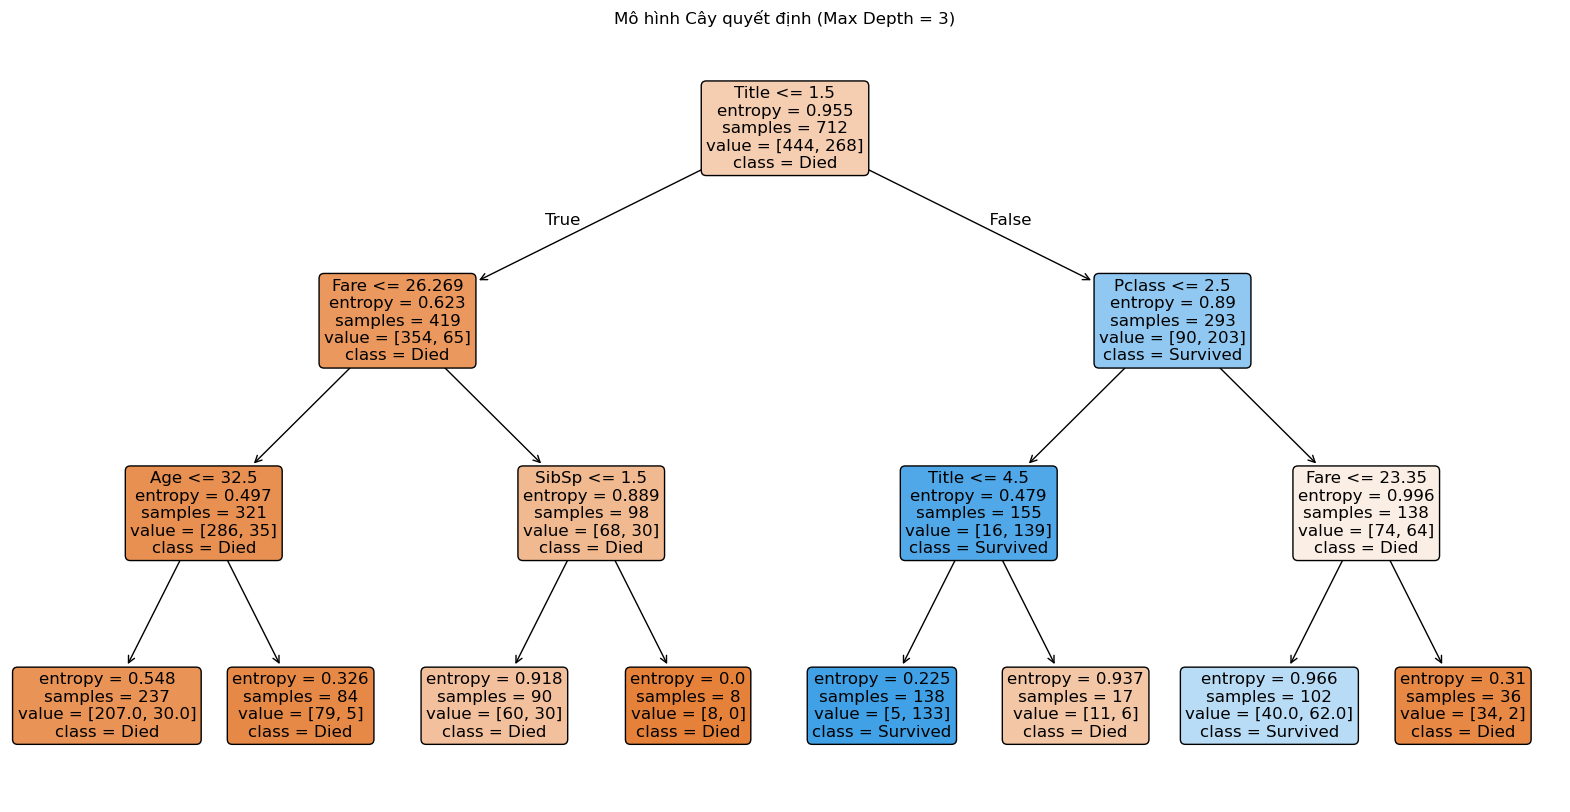

In [15]:
# Huấn luyện mô hình
dt_model = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
dt_model.fit(X_train, y_train)

# Dự đoán
y_pred_dt = dt_model.predict(X_val)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=X_train.columns, 
          class_names=['Died', 'Survived'], 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.title("Mô hình Cây quyết định (Max Depth = 3)")
plt.show()

**Phân tích hình vẽ:**
* **Nút gốc (Root Node):** Cây hỏi câu đầu tiên là về danh xưng hoặc giới tính (ví dụ `Title <= 1.5` nghĩa là Mr). Đây là yếu tố quan trọng nhất.
* **Màu sắc:** Màu cam thể hiện nhóm "Chết" (Died), màu xanh thể hiện nhóm "Sống" (Survived). Màu càng đậm thì độ tinh khiết (purity) càng cao.
* Cây cho ta thấy quy luật rõ ràng: Phụ nữ và trẻ em (Title > 1.5) đi theo nhánh True có xác suất sống rất cao.

## 8. Giải thuật 2: Random Forest (Rừng ngẫu nhiên)
Random Forest tạo ra hàng trăm cây quyết định và lấy kết quả biểu quyết số đông.
Thay vì vẽ 100 cây, chúng ta sẽ vẽ **Biểu đồ mức độ quan trọng của đặc trưng (Feature Importance)**. Đây là hình ảnh trực quan quan trọng nhất của thuật toán này.

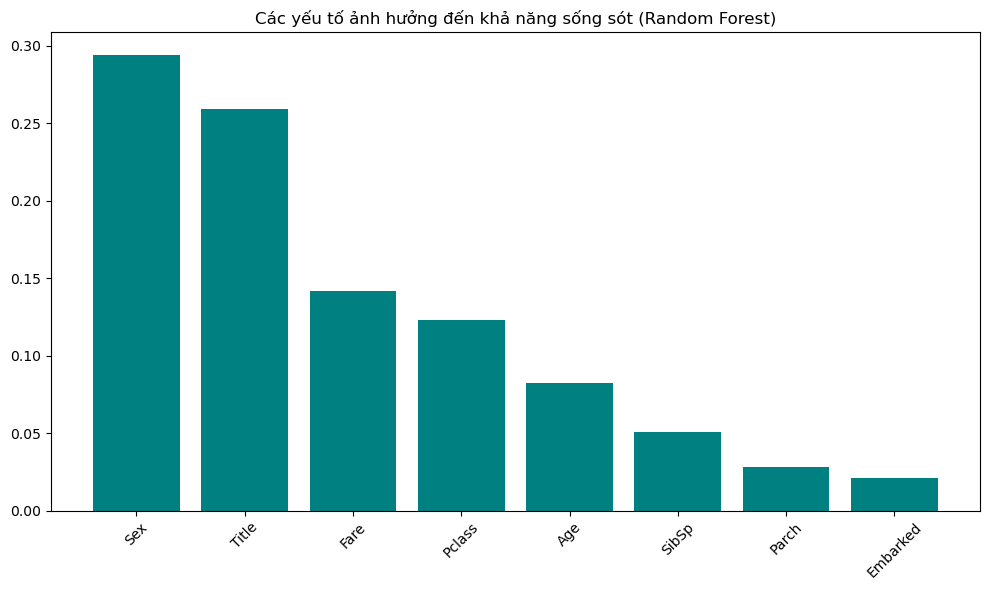

In [16]:
# Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_val)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 6))
plt.title("Các yếu tố ảnh hưởng đến khả năng sống sót (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X_train.shape[1]), features[indices], rotation=45)
plt.tight_layout()
plt.show()

**Phân tích kết quả:**
* **Accuracy:** Random Forest thường đạt khoảng **82-84%**, cao hơn Decision Tree đơn lẻ. Điều này chứng minh hiệu quả của việc trích xuất `Title` (giúp phân biệt nhóm Master và Mr).
* **Confusion Matrix:** Nhìn vào mô hình Random Forest, số lượng False Negative (Sót người sống) thường thấp hơn, nghĩa là mô hình dự báo an toàn hơn.

## 9. Dự đoán cho tập Test và Nộp bài
Cuối cùng, ta dùng mô hình tốt nhất (Random Forest) để dự đoán cho 418 hành khách trong file `test.csv`.
Chúng ta cũng so sánh kết quả này với file `gender_submission.csv` (Baseline: Nữ sống, Nam chết) để xem sự cải thiện.

In [17]:
# Dự đoán trên tập Test (thực tế)
final_predictions = rf_model.predict(test_df)

# So sánh với Baseline (Gender Submission)
baseline_pred = df_submission['Survived']
similarity = accuracy_score(baseline_pred, final_predictions)

print(f"Độ tương đồng với quy luật 'Chỉ dựa vào giới tính': {similarity:.2%}")
print("Điều này có nghĩa là mô hình đã tìm ra khoảng {:.1f}% trường hợp ngoại lệ (VD: Phụ nữ chết hoặc Nam giới sống).".format((1-similarity)*100))

# Tạo file submission
output = pd.DataFrame({'PassengerId': df_test.index + 892, 'Survived': final_predictions}) 

output['PassengerId'] = df_submission['PassengerId']

output.to_csv('advanced_titanic_submission.csv', index=False)
print("Đã lưu file: advanced_titanic_submission.csv")
display(output.head())

Độ tương đồng với quy luật 'Chỉ dựa vào giới tính': 91.87%
Điều này có nghĩa là mô hình đã tìm ra khoảng 8.1% trường hợp ngoại lệ (VD: Phụ nữ chết hoặc Nam giới sống).
Đã lưu file: advanced_titanic_submission.csv


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
